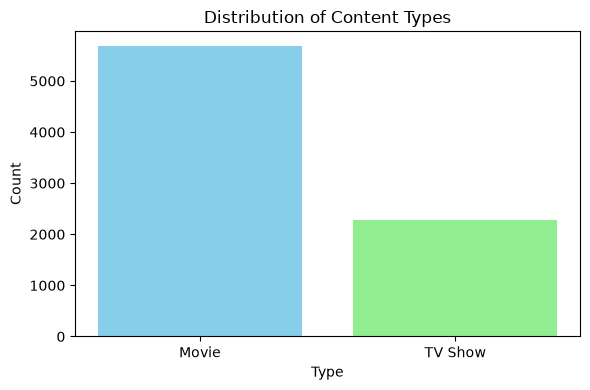

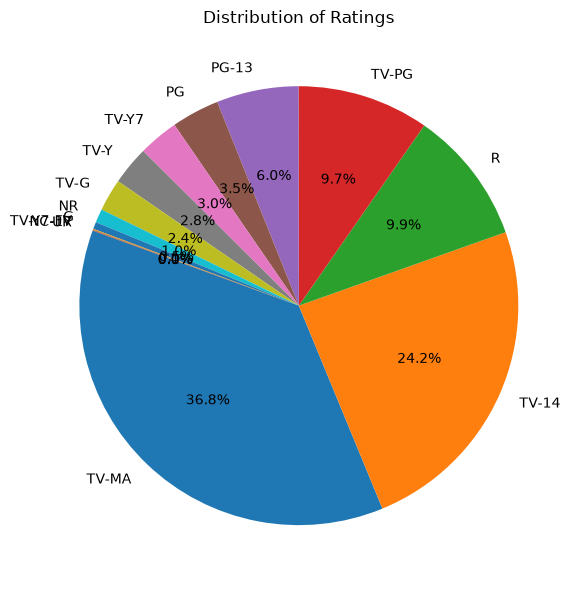

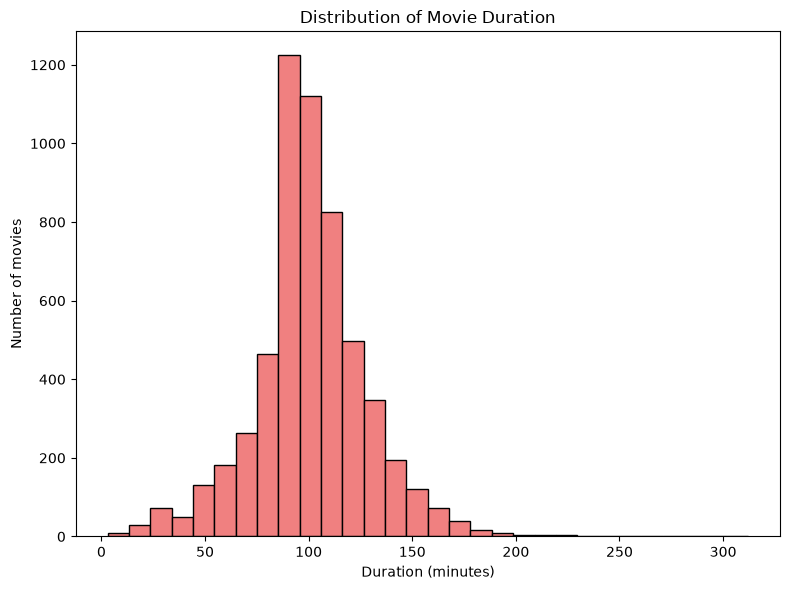

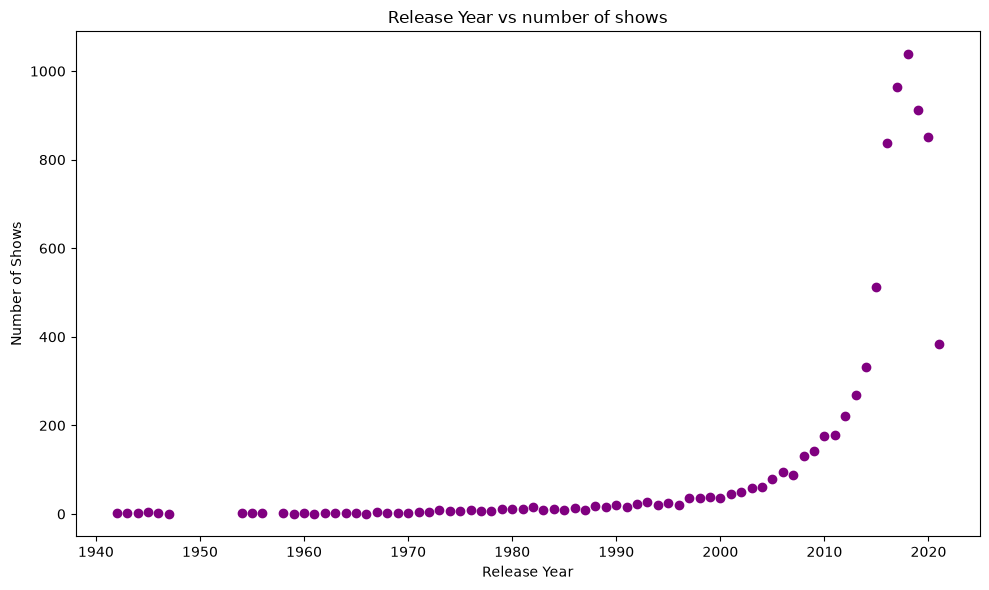

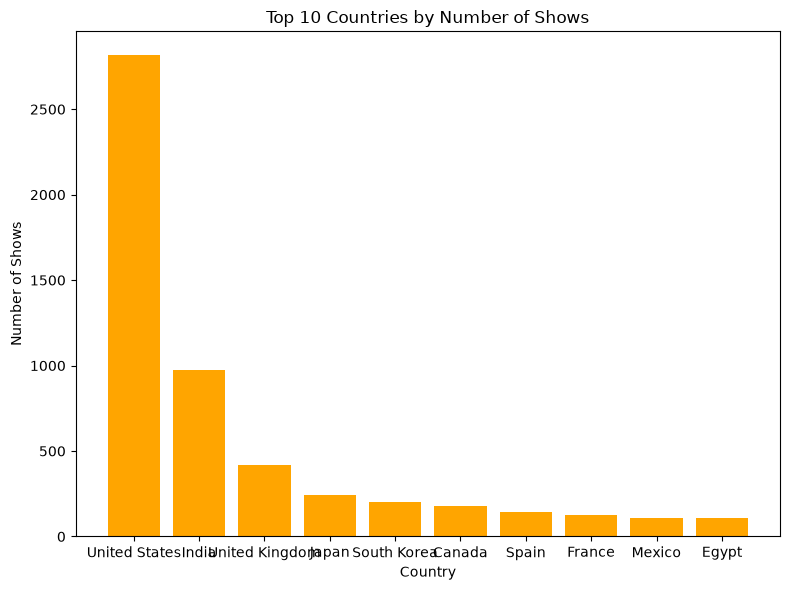

Index(['Movie', 'TV Show'], dtype='str', name='type')


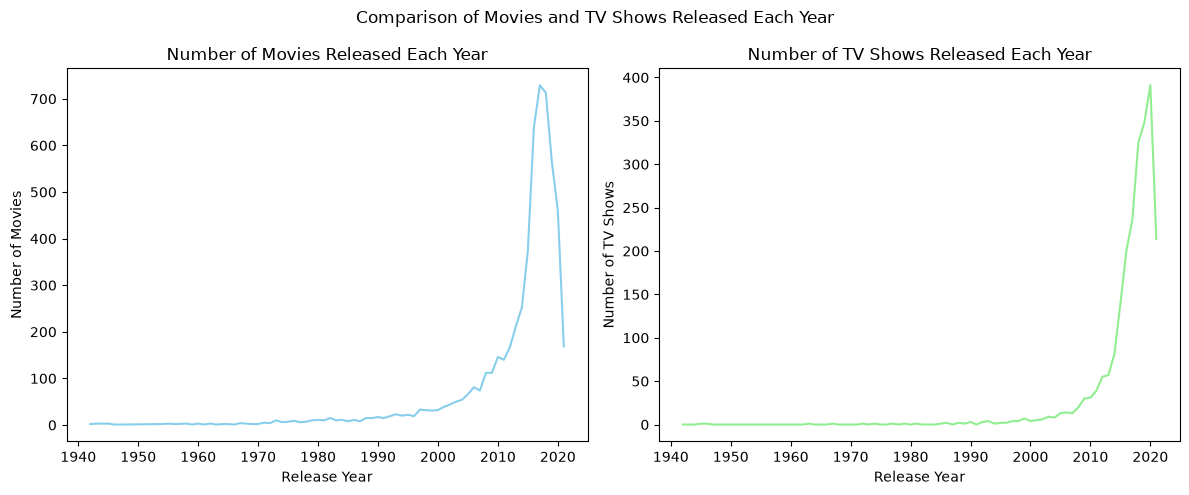

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv('netflix_titles.csv')
df = df.dropna(subset=['type', 'release_year','rating','country', 'duration'])
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values,color=['skyblue','lightgreen'])
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Distribution of Content Types')
plt.tight_layout()
plt.savefig('movies_vs_shows.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=160)
plt.title('Distribution of Ratings')
plt.tight_layout()
plt.savefig('ratings_distribution.png')
plt.show()

movie_df =df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.savefig('movie_vs_shows.png')
plt.show()

release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='purple')
plt.title('Release Year vs number of shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.bar(country_counts.index, country_counts.values, color='orange')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Country')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('country_distribution.png')
plt.show()

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

print(content_by_year.columns)  # sanity check the exact labels

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(content_by_year.index, content_by_year['Movie'], color='skyblue')
ax[0].set_title('Number of Movies Released Each Year')
ax[0].set_xlabel('Release Year')
ax[0].set_ylabel('Number of Movies')

ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='lightgreen')
ax[1].set_title('Number of TV Shows Released Each Year')
ax[1].set_xlabel('Release Year')
ax[1].set_ylabel('Number of TV Shows')

fig.suptitle('Comparison of Movies and TV Shows Released Each Year')

plt.tight_layout()
plt.savefig('movies_vs_TV_shows_by_year.png')
plt.show()